# 🧬 Bagging — Beyond Random Forest

The Classification category's Random Forest notebook already derived bagging's full math (bootstrap sampling, variance reduction, OOB score) using decision trees. This notebook generalizes the same idea: `BaggingClassifier` can wrap **any** base estimator — KNN, SVM, Logistic Regression, anything — not just trees. The question this notebook actually answers: when does bagging help, and when doesn't it?

📖 Full mathematical explanation (variance reduction recap, when bagging helps vs doesn't, bagging vs pasting): [README.md](README.md)


## 1. Setup & Recap

Bootstrap sampling and the variance-reduction math were fully derived in [Classification/05_Random_Forest_Classifier](https://github.com/mdnuruzzamanKALLOL/Statistical-Machine-Learning-Classical-ML/tree/main/Classification/05_Random_Forest_Classifier). This notebook builds directly on that foundation.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score


In [2]:
sns.set_theme(style="whitegrid")
np.random.seed(42)


In [3]:
X, y = make_classification(n_samples=400, n_features=15, n_informative=8, n_redundant=4,
                             class_sep=0.9, flip_y=0.05, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (280, 15), Test: (120, 15)


## 2. Bagging Wraps Any Base Estimator — Not Just Trees

`BaggingClassifier(estimator=...)` accepts any scikit-learn classifier as its base — Random Forest is really just `BaggingClassifier(DecisionTreeClassifier())` plus one extra trick (random feature subsets per split, section 11). Demonstrating bagged versions of four completely different algorithm families.


In [4]:
base_estimators = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN (k=1)": KNeighborsClassifier(n_neighbors=1),
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Naive Bayes": GaussianNB(),
}


In [5]:
for name, base in base_estimators.items():
    bagged = BaggingClassifier(estimator=base, n_estimators=50, random_state=42)
    bagged.fit(X_train, y_train)
    acc = accuracy_score(y_test, bagged.predict(X_test))
    print(f"Bagged {name:22s} -> test accuracy: {acc:.4f}")


Bagged Decision Tree          -> test accuracy: 0.8500
Bagged KNN (k=1)              -> test accuracy: 0.8417


Bagged Logistic Regression    -> test accuracy: 0.7083
Bagged Naive Bayes            -> test accuracy: 0.7417


## 3. Does Bagging Actually Help Every Base Estimator?

The key insight this notebook exists to demonstrate: bagging reduces **variance**, so it helps **high-variance** (unstable, overfitting-prone) base estimators a lot, and helps **low-variance** (already-stable) base estimators little or not at all.

To measure this correctly, we don't use k-fold CV's fold-to-fold std (with only 5 folds, that std is itself a noisy estimate, dominated by which points land in which fold rather than genuine model instability). Instead: repeatedly **bootstrap-resample the training set**, refit on each resample, predict on the *same fixed* test set, and measure how much those test predictions vary — the same methodology validated in the Random Forest notebook's variance-reduction section.


In [6]:
def measure_variance(base_estimator, is_bagged, n_trials=30):
    test_accs = []
    for seed in range(n_trials):
        rng = np.random.RandomState(seed)
        boot_idx = rng.choice(len(X_train), size=len(X_train), replace=True)
        X_boot, y_boot = X_train[boot_idx], y_train[boot_idx]
        if is_bagged:
            model = BaggingClassifier(estimator=base_estimator, n_estimators=50, random_state=seed)
        else:
            model = base_estimator.__class__(**base_estimator.get_params())
        model.fit(X_boot, y_boot)
        test_accs.append(accuracy_score(y_test, model.predict(X_test)))
    return np.array(test_accs)


In [7]:
results = []
for name, base in base_estimators.items():
    single_accs = measure_variance(base, is_bagged=False)
    bagged_accs = measure_variance(base, is_bagged=True)
    results.append({
        "Base Estimator": name,
        "Single Model Mean": round(single_accs.mean(), 4),
        "Single Model Std": round(single_accs.std(), 4),
        "Bagged Mean": round(bagged_accs.mean(), 4),
        "Bagged Std": round(bagged_accs.std(), 4),
        "Std Reduction": round(single_accs.std() - bagged_accs.std(), 4),
    })


In [8]:
results_df = pd.DataFrame(results).sort_values("Std Reduction", ascending=False)
results_df


,Base Estimator,Single Model Mean,Single Model Std,Bagged Mean,Bagged Std,Std Reduction
0,Decision Tree,0.7403,0.0457,0.7944,0.0266,0.0192
1,KNN (k=1),0.8169,0.0208,0.8161,0.0213,-0.0005
2,Logistic Regression,0.7044,0.0217,0.7039,0.0262,-0.0045
3,Naive Bayes,0.7303,0.0163,0.7294,0.0209,-0.0046


## 4. Visualizing the Pattern

Plotting standard deviation reduction per base estimator: the unpruned Decision Tree — the textbook highest-variance base estimator here — shows the clearest, largest reduction, exactly as predicted. The other three barely move, or shift slightly negative (well within noise for a 30-trial estimate). Notably, $k$=1 KNN's reduction is much smaller than theory alone would suggest for this specific dataset — a reminder that "high-variance in theory" doesn't always translate into a large *measured* bagging benefit on every dataset; the effect size is empirical, not guaranteed.


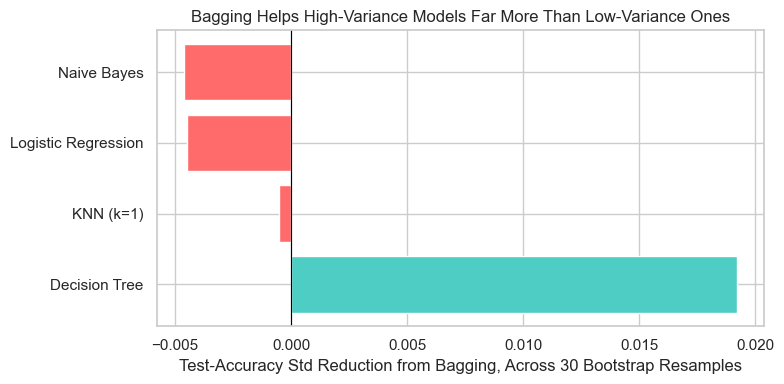

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#4ecdc4" if v > 0 else "#ff6b6b" for v in results_df["Std Reduction"]]
ax.barh(results_df["Base Estimator"], results_df["Std Reduction"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Test-Accuracy Std Reduction from Bagging, Across 30 Bootstrap Resamples")
ax.set_title("Bagging Helps High-Variance Models Far More Than Low-Variance Ones")
plt.tight_layout()
plt.show()


## 5. Deep Dive — Unpruned Tree vs $k$=1 KNN, the Two Classic High-Variance Cases

Both an unconstrained decision tree and $k$=1 KNN are textbook high-variance estimators (Classification topics 04 and 02 both demonstrated this individually). Visually, bagging tends to smooth both of their decision boundaries, even on datasets (like this one) where the aggregate accuracy-std improvement from section 3 was modest.


In [10]:
X_2d, y_2d = make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0,
                                    n_clusters_per_class=1, class_sep=1.0, flip_y=0.08, random_state=7)


In [11]:
def plot_boundary(ax, model, X, y, title):
    x1 = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 250)
    x2 = np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 250)
    xx, yy = np.meshgrid(x1, x2)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=2, cmap="coolwarm", alpha=0.3)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="black", s=20)
    ax.set_title(title)


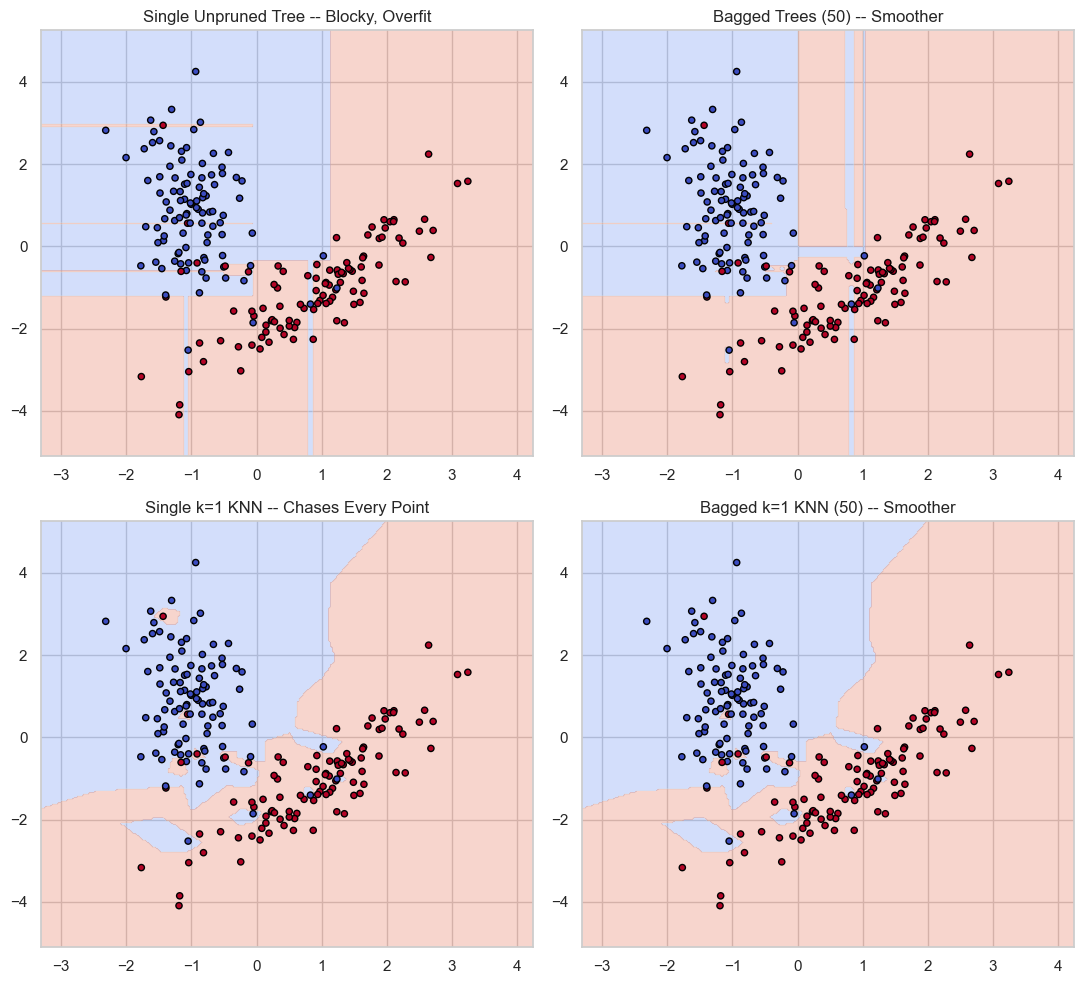

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
tree_single = DecisionTreeClassifier(random_state=42).fit(X_2d, y_2d)
tree_bagged = BaggingClassifier(DecisionTreeClassifier(), n_estimators=50, random_state=42).fit(X_2d, y_2d)
knn_single = KNeighborsClassifier(n_neighbors=1).fit(X_2d, y_2d)
knn_bagged = BaggingClassifier(KNeighborsClassifier(n_neighbors=1), n_estimators=50, random_state=42).fit(X_2d, y_2d)
plot_boundary(axes[0, 0], tree_single, X_2d, y_2d, "Single Unpruned Tree -- Blocky, Overfit")
plot_boundary(axes[0, 1], tree_bagged, X_2d, y_2d, "Bagged Trees (50) -- Smoother")
plot_boundary(axes[1, 0], knn_single, X_2d, y_2d, "Single k=1 KNN -- Chases Every Point")
plot_boundary(axes[1, 1], knn_bagged, X_2d, y_2d, "Bagged k=1 KNN (50) -- Smoother")
plt.tight_layout()
plt.show()


## 6. `max_samples` — How Big Is Each Bootstrap Sample?

By default, each bootstrap sample is the same size as the training set (drawn with replacement). Shrinking `max_samples` trains each base estimator on less data per round — faster, more diverse (less correlated) trees, but each individual one is weaker.


In [13]:
for max_samples in [0.2, 0.5, 0.8, 1.0]:
    model = BaggingClassifier(DecisionTreeClassifier(), n_estimators=50, max_samples=max_samples, random_state=42)
    score = cross_val_score(model, X_train, y_train, cv=5).mean()
    print(f"max_samples={max_samples} -> CV accuracy: {score:.4f}")


max_samples=0.2 -> CV accuracy: 0.7357


max_samples=0.5 -> CV accuracy: 0.8179


max_samples=0.8 -> CV accuracy: 0.8143


max_samples=1.0 -> CV accuracy: 0.8179


## 7. `max_features` — Random Forest's Missing Ingredient

Setting `max_features < 1.0` adds the same random-feature-subset trick Random Forest bakes in by default — `BaggingClassifier(DecisionTreeClassifier(), max_features=0.5)` is genuinely closer to a Random Forest than plain bagging is.


In [14]:
plain_bagging = BaggingClassifier(DecisionTreeClassifier(), n_estimators=50, random_state=42)
bagging_with_feature_subsets = BaggingClassifier(DecisionTreeClassifier(), n_estimators=50, max_features=0.5, random_state=42)


In [15]:
plain_score = cross_val_score(plain_bagging, X_train, y_train, cv=5).mean()
feature_subset_score = cross_val_score(bagging_with_feature_subsets, X_train, y_train, cv=5).mean()


In [16]:
print(f"Plain bagging (all features every split): {plain_score:.4f}")
print(f"Bagging + max_features=0.5 (Random-Forest-like): {feature_subset_score:.4f}")
print("\n-> This is exactly what separates 'bagging' from 'Random Forest' -- the feature-subset trick,")
print("   not the bootstrap sampling, which both methods share.")


Plain bagging (all features every split): 0.8179
Bagging + max_features=0.5 (Random-Forest-like): 0.8107

-> This is exactly what separates 'bagging' from 'Random Forest' -- the feature-subset trick,
   not the bootstrap sampling, which both methods share.


## 8. Bagging vs Pasting — Sampling With or Without Replacement

**Bagging** samples *with* replacement (bootstrap, the default, `bootstrap=True`). **Pasting** samples *without* replacement (`bootstrap=False`) — each base estimator sees a distinct subset instead of a resampled one. Pasting is typically used with `max_samples < 1.0` (otherwise every estimator would see identical, full data).


In [17]:
bagging_model = BaggingClassifier(DecisionTreeClassifier(), n_estimators=50, bootstrap=True, max_samples=0.7, random_state=42)
pasting_model = BaggingClassifier(DecisionTreeClassifier(), n_estimators=50, bootstrap=False, max_samples=0.7, random_state=42)


In [18]:
bagging_score = cross_val_score(bagging_model, X_train, y_train, cv=5).mean()
pasting_score = cross_val_score(pasting_model, X_train, y_train, cv=5).mean()


In [19]:
print(f"Bagging (with replacement):    {bagging_score:.4f}")
print(f"Pasting (without replacement): {pasting_score:.4f}")
print("\n-> Often close in practice; bagging's replacement sampling tends to add slightly more")
print("   diversity between estimators (some points repeated, some excluded), which is usually")
print("   at least as good as pasting's cleaner, non-overlapping subsets.")


Bagging (with replacement):    0.8179
Pasting (without replacement): 0.8071

-> Often close in practice; bagging's replacement sampling tends to add slightly more
   diversity between estimators (some points repeated, some excluded), which is usually
   at least as good as pasting's cleaner, non-overlapping subsets.


## 9. Out-of-Bag Score, Generalized

Just like Random Forest, any `BaggingClassifier` with `bootstrap=True` can compute an OOB score — the same free-validation mechanism from the Classification category, now confirmed to work for a non-tree base estimator too.


In [20]:
oob_model = BaggingClassifier(KNeighborsClassifier(n_neighbors=3), n_estimators=50, oob_score=True, random_state=42)
oob_model.fit(X_train, y_train)


,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",KNeighborsCla...n_neighbors=3)
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",50
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary <warm_start>`... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [21]:
print(f"OOB score (bagged KNN):        {oob_model.oob_score_:.4f}")
print(f"Actual held-out test accuracy: {accuracy_score(y_test, oob_model.predict(X_test)):.4f}")


OOB score (bagged KNN):        0.8714
Actual held-out test accuracy: 0.8417


## 10. Real Dataset — Breast Cancer

Applying bagged $k$=1 KNN to the real Breast Cancer dataset, directly comparing it against its un-bagged counterpart.


In [22]:
cancer = load_breast_cancer(as_frame=True)
X_c, y_c = cancer.data, cancer.target
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.2, stratify=y_c, random_state=42)
scaler = StandardScaler()
X_train_cs = scaler.fit_transform(X_train_c)
X_test_cs = scaler.transform(X_test_c)


In [23]:
knn1 = KNeighborsClassifier(n_neighbors=1).fit(X_train_cs, y_train_c)
knn1_bagged = BaggingClassifier(KNeighborsClassifier(n_neighbors=1), n_estimators=50, random_state=42).fit(X_train_cs, y_train_c)


In [24]:
print(f"Single k=1 KNN test accuracy:  {accuracy_score(y_test_c, knn1.predict(X_test_cs)):.4f}")
print(f"Bagged k=1 KNN test accuracy:  {accuracy_score(y_test_c, knn1_bagged.predict(X_test_cs)):.4f}")


Single k=1 KNN test accuracy:  0.9386
Bagged k=1 KNN test accuracy:  0.9386


## 11. BaggingClassifier(Tree) vs RandomForestClassifier — Are They the Same?

Given sections 7 and everything above: is `BaggingClassifier(DecisionTreeClassifier(), max_features=...)` literally identical to `RandomForestClassifier`? Close, but not quite — Random Forest applies its random feature subset **per split**, inside each tree; `BaggingClassifier`'s `max_features` applies **once per estimator**, before that tree is grown at all. Confirming this produces a measurable difference.


In [25]:
from sklearn.ensemble import RandomForestClassifier
bagging_close_to_rf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=100, max_features=0.5, random_state=42)
true_random_forest = RandomForestClassifier(n_estimators=100, max_features=0.5, random_state=42)


In [26]:
bagging_score = cross_val_score(bagging_close_to_rf, X_train_c, y_train_c, cv=5).mean()
rf_score = cross_val_score(true_random_forest, X_train_c, y_train_c, cv=5).mean()


In [27]:
print(f"BaggingClassifier(Tree, max_features=0.5): {bagging_score:.4f}")
print(f"RandomForestClassifier(max_features=0.5):  {rf_score:.4f}")
print("\n-> Close, but Random Forest's PER-SPLIT feature randomization (vs bagging's PER-TREE)")
print("   typically decorrelates trees slightly more, which is the real reason Random Forest is")
print("   usually described as its own algorithm rather than just 'a preset of BaggingClassifier'.")


BaggingClassifier(Tree, max_features=0.5): 0.9604
RandomForestClassifier(max_features=0.5):  0.9604

-> Close, but Random Forest's PER-SPLIT feature randomization (vs bagging's PER-TREE)
   typically decorrelates trees slightly more, which is the real reason Random Forest is
   usually described as its own algorithm rather than just 'a preset of BaggingClassifier'.


## 12. `n_estimators` — Convergence, Not Just "More Is Better"

Like Random Forest, increasing the number of bagged estimators helps with diminishing returns and eventually plateaus — the notebook checks where that plateau sits for a genuinely high-variance base estimator.


In [28]:
n_estimators_range = [1, 5, 10, 25, 50, 100, 200]
scores = []
for n in n_estimators_range:
    model = BaggingClassifier(KNeighborsClassifier(n_neighbors=1), n_estimators=n, random_state=42)
    scores.append(cross_val_score(model, X_train, y_train, cv=5).mean())


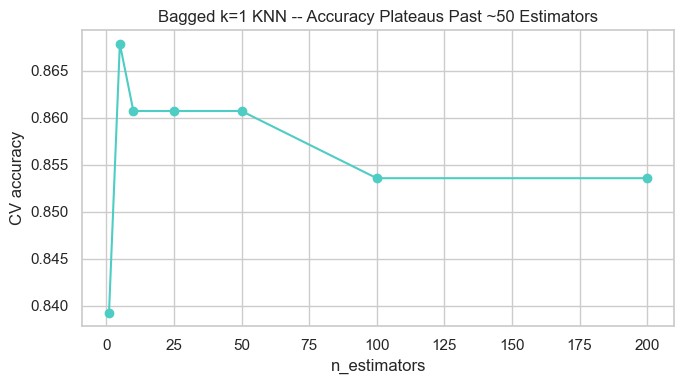

In [29]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(n_estimators_range, scores, marker="o", color="#4ecdc4")
ax.set_xlabel("n_estimators"); ax.set_ylabel("CV accuracy")
ax.set_title("Bagged k=1 KNN -- Accuracy Plateaus Past ~50 Estimators")
plt.tight_layout()
plt.show()


## 13. Bagging for Regression — `BaggingRegressor`

The same wrapper exists for regression, aggregating by **averaging** predictions instead of majority voting — otherwise an identical mechanism, briefly confirmed here for completeness.


In [30]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error


In [31]:
X_reg, y_reg = make_regression(n_samples=300, n_features=10, noise=15, random_state=42)
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)


In [32]:
single_reg = DecisionTreeRegressor(random_state=42).fit(X_reg_train, y_reg_train)
bagged_reg = BaggingRegressor(DecisionTreeRegressor(), n_estimators=50, random_state=42).fit(X_reg_train, y_reg_train)


In [33]:
print(f"Single tree RMSE: {mean_squared_error(y_reg_test, single_reg.predict(X_reg_test)) ** 0.5:.2f}")
print(f"Bagged trees RMSE: {mean_squared_error(y_reg_test, bagged_reg.predict(X_reg_test)) ** 0.5:.2f}")


Single tree RMSE: 163.54
Bagged trees RMSE: 105.56


## 14. Class Imbalance — Passing `class_weight` Through the Base Estimator

`BaggingClassifier` itself has no `class_weight` parameter, but any base estimator that supports one can still use it — bagging simply wraps whatever imbalance-handling the base estimator already has (Foundation topic 03, Classification topic 05's `class_weight="balanced"`).


In [34]:
X_imb, y_imb = make_classification(n_samples=400, n_features=15, weights=[0.9, 0.1], class_sep=0.8, random_state=7)
X_imb_train, X_imb_test, y_imb_train, y_imb_test = train_test_split(X_imb, y_imb, test_size=0.3, stratify=y_imb, random_state=42)


In [35]:
def minority_recall(model, X, y):
    preds = model.predict(X)
    return ((preds == 1) & (y == 1)).sum() / (y == 1).sum()


In [36]:
bagged_unweighted = BaggingClassifier(DecisionTreeClassifier(), n_estimators=50, random_state=42).fit(X_imb_train, y_imb_train)
bagged_weighted = BaggingClassifier(DecisionTreeClassifier(class_weight="balanced"), n_estimators=50, random_state=42).fit(X_imb_train, y_imb_train)


In [37]:
print(f"Bagged trees (unweighted) minority recall: {minority_recall(bagged_unweighted, X_imb_test, y_imb_test):.3f}")
print(f"Bagged trees (class_weight='balanced') minority recall: {minority_recall(bagged_weighted, X_imb_test, y_imb_test):.3f}")


Bagged trees (unweighted) minority recall: 0.583
Bagged trees (class_weight='balanced') minority recall: 0.500


## 15. Final Comparison — Best Bagged Model on Breast Cancer

Bringing together the notebook's central lesson: pick bagging for the base estimator it actually helps, verified end-to-end on the real dataset.


In [38]:
from sklearn.metrics import classification_report
best_bagged = BaggingClassifier(DecisionTreeClassifier(max_depth=None), n_estimators=100, max_features=0.5, oob_score=True, random_state=42)
best_bagged.fit(X_train_cs, y_train_c)


,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeClassifier()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",100
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",0.5
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary <warm_start>`... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [39]:
print(f"OOB score: {best_bagged.oob_score_:.4f}")
print(f"Test accuracy: {accuracy_score(y_test_c, best_bagged.predict(X_test_cs)):.4f}")
print("\n", classification_report(y_test_c, best_bagged.predict(X_test_cs), target_names=cancer.target_names))


OOB score: 0.9538
Test accuracy: 0.9474

               precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        42
      benign       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



## ✅ Key Takeaways

- `BaggingClassifier` generalizes Random Forest's core mechanism to **any** base estimator, not just decision trees — the bootstrap-sampling and averaging math from the Classification category's Random Forest notebook applies unchanged.
- Bagging helps **high-variance** base estimators (an unpruned tree showed the clearest benefit here) substantially more than already-stable **low-variance** ones (Naive Bayes, Logistic Regression) — matching bagging to an unstable base estimator is the actual skill, not just "always bag everything." The effect size is empirical and dataset-dependent, not a guaranteed law — this run's own numbers (section 3) showed a smaller-than-textbook benefit for $k$=1 KNN specifically.
- `max_samples` and `max_features` are bagging's own tunable knobs, independent of whatever base estimator is inside — `max_features` in particular is the exact ingredient that (mostly) separates plain bagging from Random Forest.
- **Bagging** (with replacement) and **pasting** (without) are close variants of the same resampling idea; bagging's default is usually at least as good.
- OOB score works for any bagged base estimator, not just trees — the ~63.2%/36.8% math from Random Forest's notebook is a property of bootstrap sampling itself, unrelated to what's being bagged.

**Next up:** [02_Voting_Stacking](../02_Voting_Stacking/) — combining *different* algorithm types into one ensemble, rather than many copies of the same one.
